# Global Prophet Component Decomposition: April vs Threshold-Matched June Desktop DAU

This notebook overlays the global desktop DAU forecast components for **April 2026** and **June 2026 (threshold-matched)**.

**Why threshold-matched June?** The canonical June run uses `holiday_threshold = -0.032` (the mozaic-forecasting-official package default), while April was fit on the older `april-metaparameter-updates` branch where the default was `-0.05`. The difference accounts for essentially all of the pre-2025 historical trend gap (June canonical sat +125k above April in pre-2025; matched, the gap is −3k). To eliminate that confound from the visual comparison, we use a June refit with `threshold = -0.05` as the primary line.

**Three series in this notebook:**
- `april` — canonical April pkl, threshold = −0.05 (blue)
- `june` — **June refit with threshold = −0.05 to match April** (red, primary)
- `june_current` — canonical June `_cap426` pkl, threshold = −0.032 (grey dashed, reference only)

**Inputs (cached parquets, produced by `tooling/prophet_decompose/decompose.py`):**
- `tmp/prophet_components_april_desktop_dau.parquet`
- `tmp/prophet_components_june_threshmatch_desktop_dau.parquet`
- `tmp/prophet_components_june_desktop_dau.parquet`

**Components plotted (linear DAU space, summed across 45 country×OS tiles):**
- `trend` — Prophet's piecewise-linear / logistic-capped long-run level
- `weekly` — Prophet's conditional weekly seasonality (`weekly_recent` + `weekly_historical`)
- `yearly` — Prophet's yearly seasonality
- `holidays` — Mozaic's holiday detrending effect

**Caveat:** ~17 of 45 tiles use linear-growth-on-log-transformed-y. Components are converted to linear-space via `exp(trend) * (exp(component) - 1)`, leaving a small cross-term residual (verified small in the residual cell at the bottom).


In [1]:
# setup
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# Three runs:
# - APRIL: canonical April 2026 forecast (threshold = -0.05, pre-cap-fix code path)
# - JUNE_CURRENT: canonical June 2026 _cap426 forecast (threshold = -0.032, package default)
# - JUNE_MATCH:   June refit with threshold = -0.05 to match April (cap426 code path otherwise unchanged)
APRIL_PATH       = Path("tmp/prophet_components_april_desktop_dau.parquet")
JUNE_CURRENT_PATH = Path("tmp/prophet_components_june_desktop_dau.parquet")
JUNE_MATCH_PATH   = Path("tmp/prophet_components_june_threshmatch_desktop_dau.parquet")

APRIL_FCST_START = pd.Timestamp("2026-04-01")
JUNE_FCST_START = pd.Timestamp("2026-05-17")

APRIL_COLOR = "#1f6feb"   # blue
JUNE_COLOR = "#d63a3a"    # red — threshold-matched June (primary comparison)
JUNE_REF_COLOR = "#888"   # grey, thin/dashed — current June for context

april = pd.read_parquet(APRIL_PATH)
june_current = pd.read_parquet(JUNE_CURRENT_PATH)
june = pd.read_parquet(JUNE_MATCH_PATH)  # primary: threshold-matched

print(f"April              (thresh=-0.05):  {len(april)} rows, ds {april['ds'].min().date()} -> {april['ds'].max().date()}")
print(f"June threshmatch   (thresh=-0.05):  {len(june)} rows")
print(f"June canonical     (thresh=-0.032): {len(june_current)} rows  (reference)")


April              (thresh=-0.05):  2922 rows, ds 2020-01-01 -> 2027-12-31
June threshmatch   (thresh=-0.05):  2922 rows
June canonical     (thresh=-0.032): 2922 rows  (reference)


In [2]:
# helpers
def add_forecast_dividers(ax):
    ax.axvline(APRIL_FCST_START, color=APRIL_COLOR, ls="--", lw=0.8, alpha=0.5,
               label=f"April fcst start ({APRIL_FCST_START.date()})")
    ax.axvline(JUNE_FCST_START, color=JUNE_COLOR, ls="--", lw=0.8, alpha=0.5,
               label=f"June fcst start ({JUNE_FCST_START.date()})")


def millions(x, _=None):
    return f"{x/1e6:.0f}M"


def kilos(x, _=None):
    sign = "-" if x < 0 else ""
    return f"{sign}{abs(x)/1e3:.0f}k"


def style_levels(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(millions))
    ax.grid(alpha=0.3)


def style_deviations(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(kilos))
    ax.axhline(0, color="black", lw=0.5, alpha=0.5)
    ax.grid(alpha=0.3)


## Trend — Prophet's long-run level

Sum of per-tile trends (in linear DAU space). This is the part that drives the long-run forecast trajectory.

**Threshold-match story (red vs blue):** with both runs using `threshold = -0.05`, the pre-2025 history fits **nearly identically** (June − April ≈ −3k mean) — the historical-gap finding from the canonical comparison was entirely caused by the threshold difference. The post-fcst-start gap, however, *widens* from −162k (canonical) to **−264k** at 2026-12-15. Lowering the historical trend did not pivot the recent slope upward; it shifted the entire curve down.

**Canonical June (grey dashed):** the on-disk `_cap426` run for context.


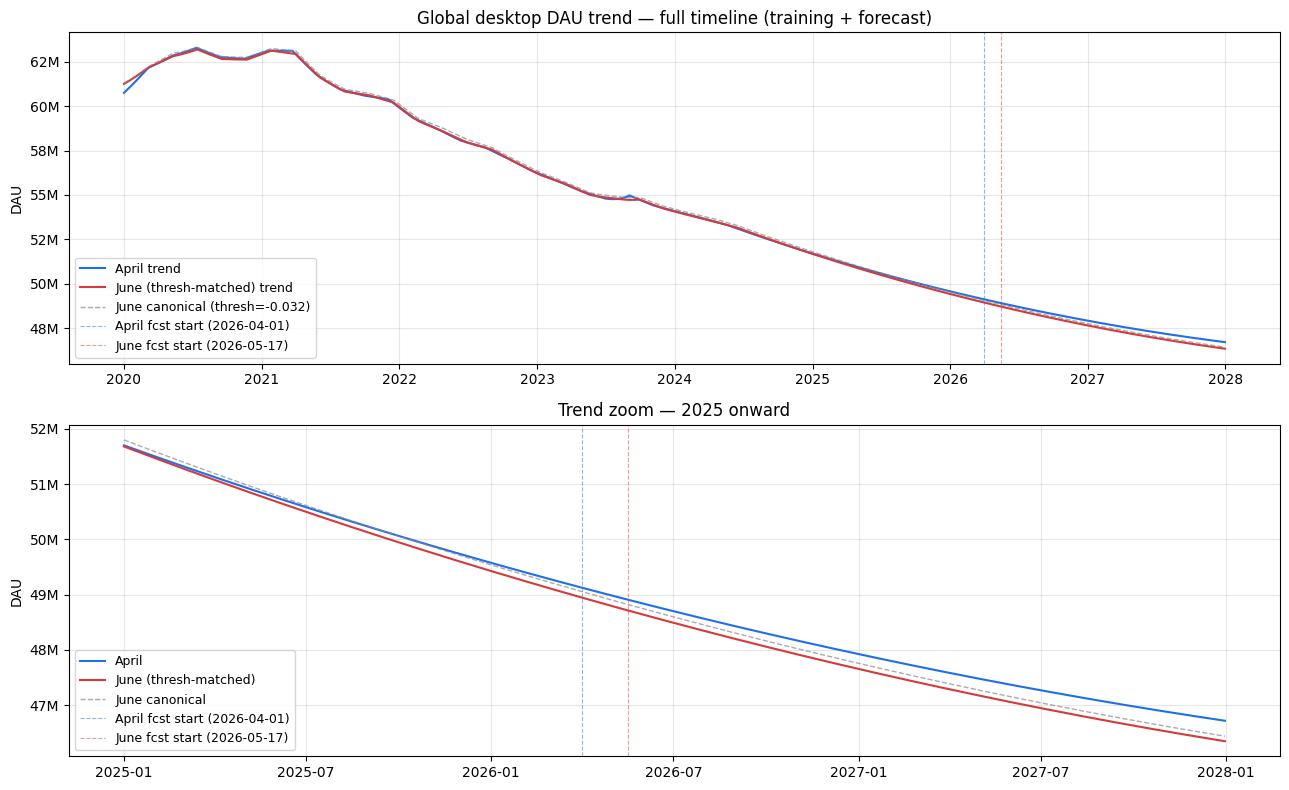

Trend at key dates:
      date   april june_match june_canon Δ_match (june_match - april) Δ_canon (june_canon - april)
2023-01-01 56.242M    56.220M    56.358M                       -22.6k                      +115.2k
2024-07-01 52.988M    53.035M    53.158M                       +47.0k                      +169.1k
2026-04-01 49.127M    48.948M    49.056M                      -178.9k                       -70.4k
2026-05-17 48.908M    48.714M    48.821M                      -194.5k                       -87.1k
2026-12-15 47.992M    47.728M    47.830M                      -263.7k                      -161.7k
2027-06-15 47.323M    47.005M    47.102M                      -318.2k                      -221.5k
2027-12-15 46.762M    46.395M    46.486M                      -366.6k                      -275.6k


In [3]:
# plot-trend
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

ax = axes[0]
ax.plot(april["ds"], april["trend"], color=APRIL_COLOR, lw=1.5, label="April trend")
ax.plot(june["ds"], june["trend"], color=JUNE_COLOR, lw=1.5, label="June (thresh-matched) trend")
ax.plot(june_current["ds"], june_current["trend"], color=JUNE_REF_COLOR, lw=1.0,
        ls="--", label="June canonical (thresh=-0.032)", alpha=0.7)
add_forecast_dividers(ax)
style_levels(ax)
ax.set_title("Global desktop DAU trend — full timeline (training + forecast)")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
zoom_start = pd.Timestamp("2025-01-01")
for df, color, lbl, ls, lw in [
    (april, APRIL_COLOR, "April", "-", 1.5),
    (june, JUNE_COLOR, "June (thresh-matched)", "-", 1.5),
    (june_current, JUNE_REF_COLOR, "June canonical", "--", 1.0),
]:
    sub = df[df.ds >= zoom_start]
    ax.plot(sub["ds"], sub["trend"], color=color, lw=lw, ls=ls, label=lbl,
            alpha=0.7 if ls == "--" else 1.0)
add_forecast_dividers(ax)
style_levels(ax)
ax.set_title("Trend zoom — 2025 onward")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

key_dates = [pd.Timestamp(d) for d in ["2023-01-01", "2024-07-01",
                                       "2026-04-01", "2026-05-17",
                                       "2026-12-15", "2027-06-15", "2027-12-15"]]
def at(df, c, d):
    s = df.loc[df.ds == d, c]
    return s.iloc[0] if len(s) else np.nan

rows = []
for d in key_dates:
    rows.append({
        "date": d.date(),
        "april": at(april, "trend", d),
        "june_match": at(june, "trend", d),
        "june_canon": at(june_current, "trend", d),
    })
summary = pd.DataFrame(rows)
summary["Δ_match (june_match - april)"] = summary["june_match"] - summary["april"]
summary["Δ_canon (june_canon - april)"] = summary["june_canon"] - summary["april"]
for c in ["april", "june_match", "june_canon"]:
    summary[c] = summary[c].map(lambda v: f"{v/1e6:.3f}M" if pd.notna(v) else "—")
for c in ["Δ_match (june_match - april)", "Δ_canon (june_canon - april)"]:
    summary[c] = summary[c].map(lambda v: f"{v/1e3:+.1f}k" if pd.notna(v) else "—")
print("Trend at key dates:")
print(summary.to_string(index=False))


## Zoom: training-end → early forecast (2025-10 → 2026-08)

The puzzle: Apr-May actuals came in *above* April's forecast (+105k/day per memory), yet the **threshold-matched** June trend now sits *below* April's. This zoom overlays:

- **Black solid:** raw actuals, 28-day MA (same data both runs see, June sees 6 extra weeks)
- **Blue solid:** April full forecast (yhat + holidays), 28d MA
- **Blue dotted:** April trend alone (no seasonality, no holidays)
- **Red solid:** June (threshold-matched) full forecast, 28d MA
- **Red dotted:** June (threshold-matched) trend alone

If the slope-flip hypothesis holds, we should see actuals *above* April's blue solid line through Apr-May but with a visibly flatter slope, and June's red dotted line bending down through that period — Prophet pivoting on a flatter recent slope from a higher base.


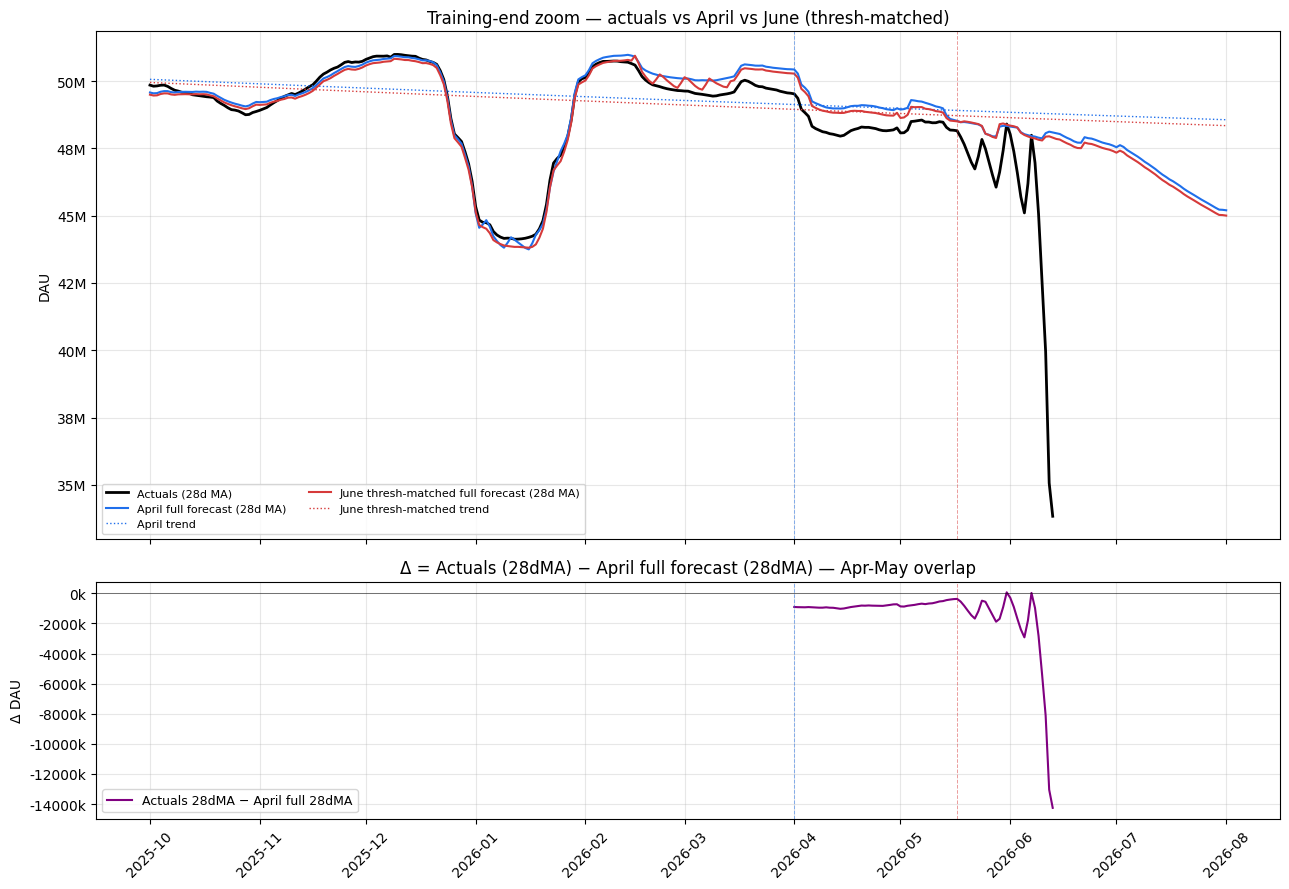

Apr-May overlap (2026-04-01 -> 2026-08-01, 123 days):
  mean Δ (actuals28dMA - April_full28dMA):    -1442.8k
  median Δ:                                    -888.7k
  Δ range:                                     -14255.7k -> +68.1k
  % days actuals > forecast (raw, not MA):     68%

  Slope of actuals 28dMA over Apr-May:        -66.97k/day  (-2009.1k/month)
  Slope of April full fcst 28dMA over Apr-May: -22.64k/day  (-679.2k/month)
  Slope diff (actuals - April):                -44.33k/day


In [4]:
# plot-zoom-training-end
zoom_start = pd.Timestamp("2025-10-01")
zoom_end = pd.Timestamp("2026-08-01")

def ma28(s):
    return s.rolling(28, min_periods=1).mean()

for df in (april, june, june_current):
    df["full_forecast"] = df["yhat"] + df["holidays"]
    df["full_forecast_ma28"] = ma28(df["full_forecast"])
    df["actuals_ma28"] = ma28(df["actuals"])

fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                          gridspec_kw={"height_ratios": [3, 1.4]}, sharex=True)

# === Top: overlay ===
ax = axes[0]
mask = lambda df: (df.ds >= zoom_start) & (df.ds <= zoom_end)
a = april[mask(april)]
j = june[mask(june)]
jc = june_current[mask(june_current)]

# Use June's actuals (extends to May 16, longer than April's training)
ax.plot(j["ds"], j["actuals_ma28"], color="black", lw=2.0, label="Actuals (28d MA)")
ax.plot(a["ds"], a["full_forecast_ma28"], color=APRIL_COLOR, lw=1.5,
        label="April full forecast (28d MA)")
ax.plot(a["ds"], a["trend"], color=APRIL_COLOR, lw=1.0, ls=":",
        label="April trend")
ax.plot(j["ds"], j["full_forecast_ma28"], color=JUNE_COLOR, lw=1.5,
        label="June thresh-matched full forecast (28d MA)")
ax.plot(j["ds"], j["trend"], color=JUNE_COLOR, lw=1.0, ls=":",
        label="June thresh-matched trend")

ax.axvline(APRIL_FCST_START, color=APRIL_COLOR, ls="--", lw=0.7, alpha=0.5)
ax.axvline(JUNE_FCST_START, color=JUNE_COLOR, ls="--", lw=0.7, alpha=0.5)
style_levels(ax)
ax.set_title("Training-end zoom — actuals vs April vs June (thresh-matched)")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=8, ncol=2)

# === Bottom: actuals minus April full forecast (28dMA) ===
ax = axes[1]
delta_df = j[["ds"]].copy()
delta_df = delta_df.merge(a[["ds", "full_forecast_ma28"]].rename(columns={"full_forecast_ma28": "april_full_ma28"}),
                          on="ds", how="left")
delta_df["actuals_ma28"] = j["actuals_ma28"].values
delta_df["delta"] = delta_df["actuals_ma28"] - delta_df["april_full_ma28"]
post_apr_start = delta_df["ds"] >= APRIL_FCST_START
delta_df.loc[~post_apr_start, "delta"] = np.nan

ax.plot(delta_df["ds"], delta_df["delta"], color="purple", lw=1.5,
        label="Actuals 28dMA − April full 28dMA")
ax.axhline(0, color="black", lw=0.6, alpha=0.6)
ax.axvline(APRIL_FCST_START, color=APRIL_COLOR, ls="--", lw=0.7, alpha=0.5)
ax.axvline(JUNE_FCST_START, color=JUNE_COLOR, ls="--", lw=0.7, alpha=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(kilos))
ax.grid(alpha=0.3)
ax.set_title("Δ = Actuals (28dMA) − April full forecast (28dMA) — Apr-May overlap")
ax.set_ylabel("Δ DAU")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# === Numerics ===
overlap = delta_df[delta_df["ds"] >= APRIL_FCST_START].copy()
print(f"Apr-May overlap ({overlap['ds'].min().date()} -> {overlap['ds'].max().date()}, {len(overlap)} days):")
print(f"  mean Δ (actuals28dMA - April_full28dMA):    {overlap['delta'].mean()/1e3:+.1f}k")
print(f"  median Δ:                                    {overlap['delta'].median()/1e3:+.1f}k")
print(f"  Δ range:                                     {overlap['delta'].min()/1e3:+.1f}k -> {overlap['delta'].max()/1e3:+.1f}k")
print(f"  % days actuals > forecast (raw, not MA):     {(j.loc[mask(j) & (j.ds >= APRIL_FCST_START), 'actuals'] > a.loc[mask(a) & (a.ds >= APRIL_FCST_START), 'full_forecast'].values).mean():.0%}")

# Slope of actuals 28dMA over Apr-May (the "slope flip" check)
sub = overlap.dropna(subset=["actuals_ma28"]).copy()
sub["t"] = (sub["ds"] - sub["ds"].min()).dt.days
slope_actuals = np.polyfit(sub["t"], sub["actuals_ma28"], 1)[0]
slope_april_fcst = np.polyfit(sub["t"], sub["april_full_ma28"], 1)[0]
print(f"\n  Slope of actuals 28dMA over Apr-May:        {slope_actuals/1e3:+.2f}k/day  ({slope_actuals*30/1e3:+.1f}k/month)")
print(f"  Slope of April full fcst 28dMA over Apr-May: {slope_april_fcst/1e3:+.2f}k/day  ({slope_april_fcst*30/1e3:+.1f}k/month)")
print(f"  Slope diff (actuals - April):                {(slope_actuals-slope_april_fcst)/1e3:+.2f}k/day")


## Weekly seasonality

Sum of per-tile weekly seasonality contributions. Prophet runs **conditional** weekly seasonality — separate basis for the recent 13 weeks of training vs everything before. Only the *recent* basis propagates into the forecast horizon, so what you see post-fcst-start is what the model has decided the current day-of-week pattern looks like.

Bottom panel: average weekly shape over the first 12 weeks of each forecast period.


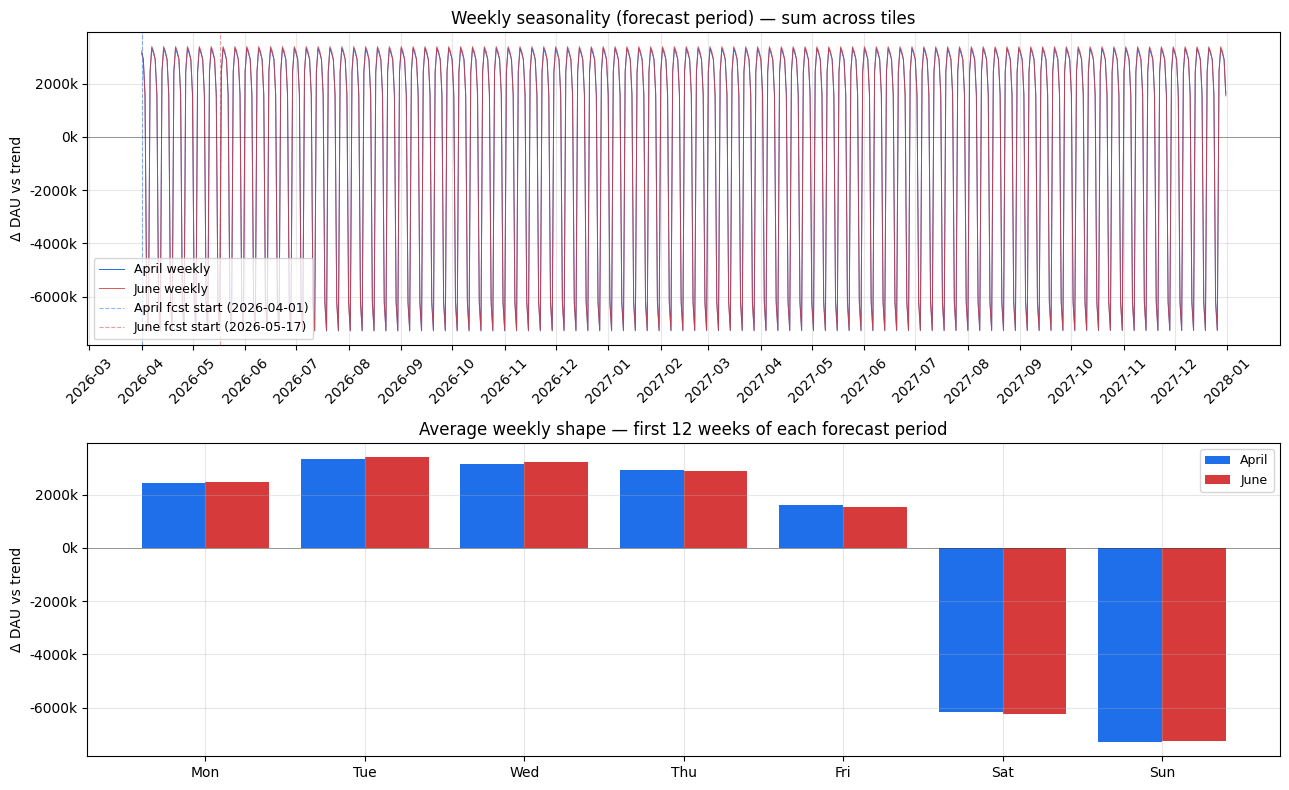

In [5]:
# plot-weekly
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: full forecast-period overlay
ax = axes[0]
fc_start = min(APRIL_FCST_START, JUNE_FCST_START)
ax.plot(april[april.ds >= fc_start]["ds"], april[april.ds >= fc_start]["weekly"],
        color=APRIL_COLOR, lw=0.7, label="April weekly")
ax.plot(june[june.ds >= fc_start]["ds"], june[june.ds >= fc_start]["weekly"],
        color=JUNE_COLOR, lw=0.7, label="June weekly", alpha=0.85)
add_forecast_dividers(ax)
style_deviations(ax)
ax.set_title("Weekly seasonality (forecast period) — sum across tiles")
ax.set_ylabel("Δ DAU vs trend")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

# Bottom: average weekly shape over first 12 weeks post-forecast-start
ax = axes[1]
def avg_weekly_shape(df, fc_start, weeks=12):
    sub = df[(df.ds >= fc_start) & (df.ds < fc_start + pd.Timedelta(weeks=weeks))].copy()
    sub["dow"] = sub["ds"].dt.day_name().str[:3]
    return sub.groupby("dow", sort=False)["weekly"].mean().reindex(
        ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    )

april_shape = avg_weekly_shape(april, APRIL_FCST_START)
june_shape = avg_weekly_shape(june, JUNE_FCST_START)

x = np.arange(7)
width = 0.4
ax.bar(x - width/2, april_shape.values, width=width, color=APRIL_COLOR, label="April")
ax.bar(x + width/2, june_shape.values, width=width, color=JUNE_COLOR, label="June")
ax.set_xticks(x)
ax.set_xticklabels(april_shape.index)
style_deviations(ax)
ax.set_title("Average weekly shape — first 12 weeks of each forecast period")
ax.set_ylabel("Δ DAU vs trend")
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


## Yearly seasonality

Sum of per-tile yearly seasonality. This component repeats each calendar year. The interesting comparison is whether April and June *learned the same yearly shape* — a divergence here would suggest the additional ~6 weeks of training data in June reshaped Prophet's inference about the annual cycle.

Bottom panel: collapse all years onto a single day-of-year axis so the shape comparison is direct.


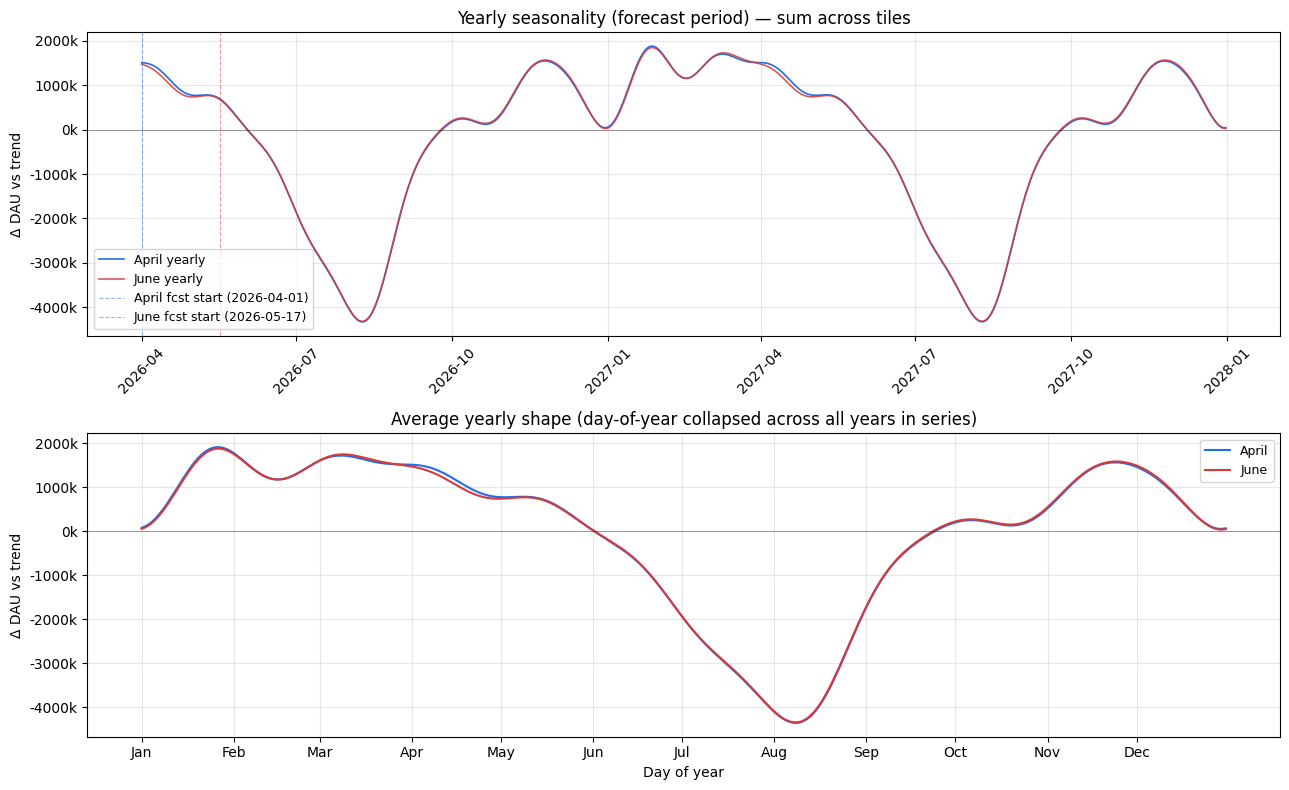

In [6]:
# plot-yearly
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: yearly time-series overlay (forecast period)
ax = axes[0]
fc_start = min(APRIL_FCST_START, JUNE_FCST_START)
ax.plot(april[april.ds >= fc_start]["ds"], april[april.ds >= fc_start]["yearly"],
        color=APRIL_COLOR, lw=1.2, label="April yearly")
ax.plot(june[june.ds >= fc_start]["ds"], june[june.ds >= fc_start]["yearly"],
        color=JUNE_COLOR, lw=1.2, label="June yearly", alpha=0.85)
add_forecast_dividers(ax)
style_deviations(ax)
ax.set_title("Yearly seasonality (forecast period) — sum across tiles")
ax.set_ylabel("Δ DAU vs trend")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

# Bottom: average yearly shape, day-of-year collapsed
ax = axes[1]
def avg_yearly_shape(df):
    sub = df.copy()
    sub["doy"] = sub["ds"].dt.dayofyear
    return sub.groupby("doy")["yearly"].mean()

april_yearly = avg_yearly_shape(april)
june_yearly = avg_yearly_shape(june)
ax.plot(april_yearly.index, april_yearly.values, color=APRIL_COLOR, lw=1.5, label="April")
ax.plot(june_yearly.index, june_yearly.values, color=JUNE_COLOR, lw=1.5, label="June")
style_deviations(ax)
ax.set_title("Average yearly shape (day-of-year collapsed across all years in series)")
ax.set_xlabel("Day of year")
ax.set_ylabel("Δ DAU vs trend")

# Month tick marks on x
month_starts = pd.to_datetime([f"2024-{m:02d}-01" for m in range(1, 13)]).dayofyear
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


## Holidays — Mozaic's holiday effect

Mozaic's holiday detrender (not Prophet's holiday module) is what handles holiday spikes.

- **Training period:** `raw_historical_data - holiday_detrended_historical_data` (per tile, then summed)
- **Forecast period:** the median of `forecasted_holiday_impacts` (per tile, then summed)

Desktop DAU drops on most holidays so values are mostly negative.


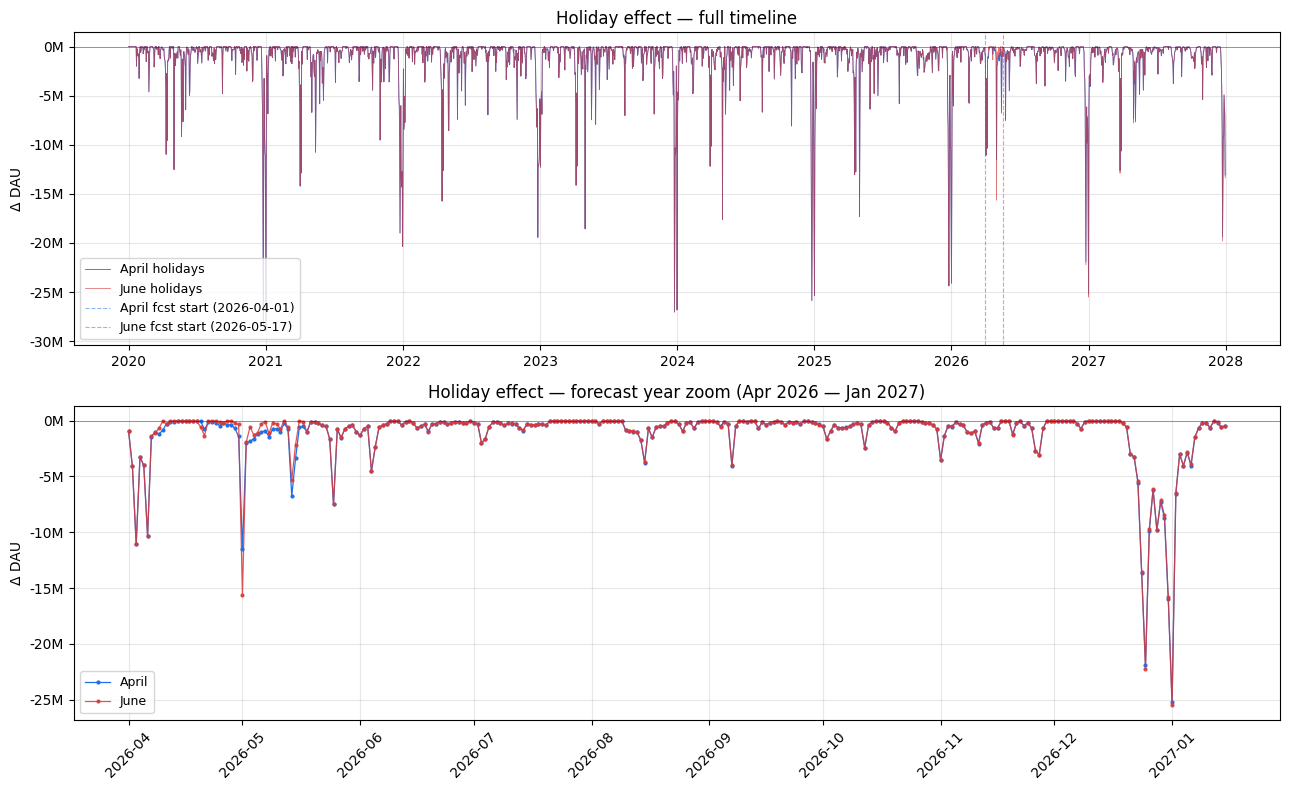

In [7]:
# plot-holidays
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: full timeline holidays (mostly zeros, with spikes)
ax = axes[0]
ax.plot(april["ds"], april["holidays"], color=APRIL_COLOR, lw=0.6, label="April holidays")
ax.plot(june["ds"], june["holidays"], color=JUNE_COLOR, lw=0.6, label="June holidays", alpha=0.7)
add_forecast_dividers(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(millions))
ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.grid(alpha=0.3)
ax.set_title("Holiday effect — full timeline")
ax.set_ylabel("Δ DAU")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Bottom: 2026 forecast period zoom to see the holiday calendar match
ax = axes[1]
zoom_start = pd.Timestamp("2026-04-01")
zoom_end = pd.Timestamp("2027-01-15")
mask_a = (april.ds >= zoom_start) & (april.ds <= zoom_end)
mask_j = (june.ds >= zoom_start) & (june.ds <= zoom_end)
ax.plot(april[mask_a]["ds"], april[mask_a]["holidays"], color=APRIL_COLOR, lw=0.9,
        marker="o", markersize=2, label="April")
ax.plot(june[mask_j]["ds"], june[mask_j]["holidays"], color=JUNE_COLOR, lw=0.9,
        marker="o", markersize=2, label="June", alpha=0.85)
ax.yaxis.set_major_formatter(plt.FuncFormatter(millions))
ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.grid(alpha=0.3)
ax.set_title("Holiday effect — forecast year zoom (Apr 2026 — Jan 2027)")
ax.set_ylabel("Δ DAU")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## yhat — final Prophet output (pre-holiday-addback)

Final summed Prophet output `yhat = trend + weekly + yearly` across all tiles, in linear DAU space. This is what the model produces *before* Mozaic adds holiday effects back. The downstream Mozaic pipeline produces the final forecast as `yhat + holidays`.


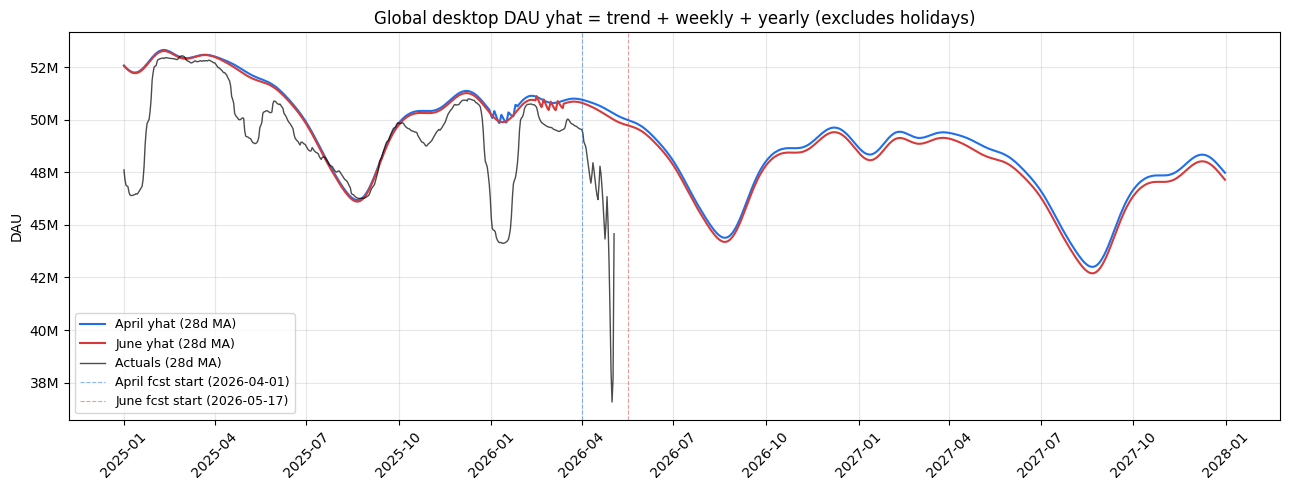

In [8]:
# plot-yhat
fig, ax = plt.subplots(figsize=(13, 5))

# 28-day MA for legibility (raw yhat has noisy weekly oscillation)
def ma(s, w=28):
    return s.rolling(w, min_periods=1).mean()

april_ma = april.copy()
april_ma["yhat_ma28"] = ma(april["yhat"])
april_ma["actuals_ma28"] = ma(april["actuals"])
june_ma = june.copy()
june_ma["yhat_ma28"] = ma(june["yhat"])
june_ma["actuals_ma28"] = ma(june["actuals"])

zoom_start = pd.Timestamp("2025-01-01")
mask_a = april_ma.ds >= zoom_start
mask_j = june_ma.ds >= zoom_start

ax.plot(april_ma[mask_a]["ds"], april_ma[mask_a]["yhat_ma28"],
        color=APRIL_COLOR, lw=1.5, label="April yhat (28d MA)")
ax.plot(june_ma[mask_j]["ds"], june_ma[mask_j]["yhat_ma28"],
        color=JUNE_COLOR, lw=1.5, label="June yhat (28d MA)")

# Overlay actuals (same series for both, but each label has its own training window)
both_actuals = (april_ma[mask_a]["actuals_ma28"]
                .combine_first(june_ma.set_index("ds")["actuals_ma28"]))
ax.plot(april_ma[mask_a]["ds"], april_ma[mask_a]["actuals_ma28"],
        color="black", lw=1.0, label="Actuals (28d MA)", alpha=0.7)

add_forecast_dividers(ax)
style_levels(ax)
ax.set_title("Global desktop DAU yhat = trend + weekly + yearly (excludes holidays)")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Decomposition residual

Per-tile, for **logistic-growth tiles** (28 of 45) Prophet's components are additive in linear DAU space, so `trend + weekly + yearly = yhat` exactly. For **linear-growth tiles** (17 of 45), Prophet operates on `log(y+1)`, and the conversion to linear-space contributions leaves a multiplicative cross-term residual.

This cell checks that the residual is small enough that the component-level comparison is meaningful. If the residual were comparable in magnitude to the seasonal components, we'd need a Shapley-style decomposition instead.


label  rows residual_mean residual_std residual_abs_max seasonal_abs_mean residual_std_pct_of_seasonal
april  2922         +249k      +1,958k          +6,699k           +7,760k                        25.2%
 june  2922         +251k      +1,959k          +6,718k           +7,811k                        25.1%


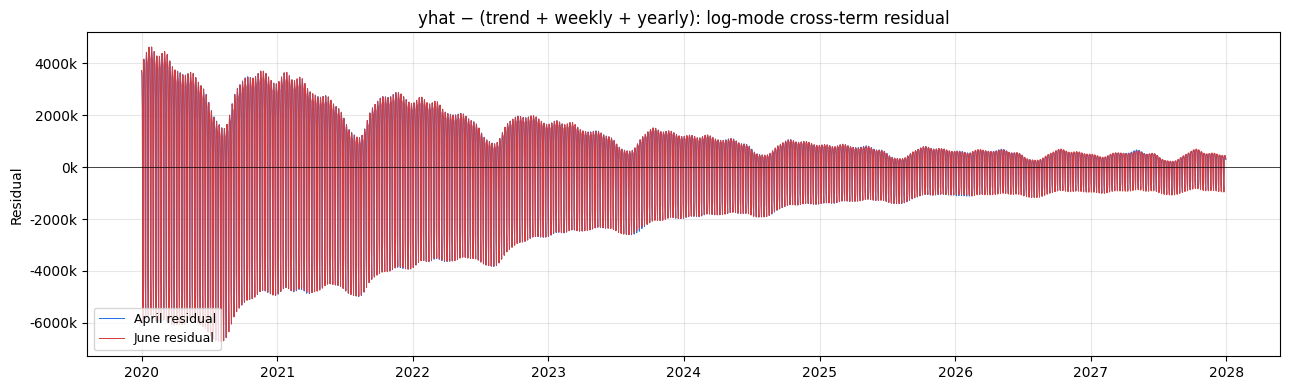

In [9]:
# residual-diagnostic
def residual_summary(df, label):
    r = df["yhat"] - (df["trend"] + df["weekly"] + df["yearly"])
    seasonal_scale = (df["weekly"].abs() + df["yearly"].abs()).mean()
    return pd.DataFrame({
        "label": [label],
        "rows": [len(df)],
        "residual_mean": [r.mean()],
        "residual_std": [r.std()],
        "residual_abs_max": [r.abs().max()],
        "seasonal_abs_mean": [seasonal_scale],
        "residual_std_pct_of_seasonal": [r.std() / seasonal_scale * 100],
    })

summary = pd.concat([
    residual_summary(april, "april"),
    residual_summary(june, "june"),
], ignore_index=True)
for c in ["residual_mean", "residual_std", "residual_abs_max", "seasonal_abs_mean"]:
    summary[c] = summary[c].map(lambda v: f"{v/1e3:+,.0f}k")
summary["residual_std_pct_of_seasonal"] = summary["residual_std_pct_of_seasonal"].map(lambda v: f"{v:.1f}%")
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 4))
for df, color, lbl in [(april, APRIL_COLOR, "April"), (june, JUNE_COLOR, "June")]:
    r = df["yhat"] - (df["trend"] + df["weekly"] + df["yearly"])
    ax.plot(df["ds"], r, color=color, lw=0.7, label=f"{lbl} residual")
ax.axhline(0, color="black", lw=0.5)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(kilos))
ax.set_title("yhat − (trend + weekly + yearly): log-mode cross-term residual")
ax.set_ylabel("Residual")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()
